# EmporiUm Book Store
I am anazlyzing sales territory manager Miami Vue and comparing sales to Bo Heap, in the NorthEast region. For states New Jersey(Miami Vue) and Massachusetts(Bo Heap). New Jersey has 16 locations and Massachusetts has 18 store locations. This data is over a 4 year period from 2022 -2025. And at the end I will proivde my recommendation on where my assigned territory manager Miami Vue should focus on for the next quarter. 

In [178]:
import pandas as pd
import numpy as np


In [22]:
df1= pd.read_csv('customer_list.csv')

In [23]:
df1.info()
#521 non null 
#dtype: 1 string
#1 column

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    str  
dtypes: str(1)
memory usage: 4.2 KB


In [358]:
df2 = pd.read_csv('ProductCategories.csv')

In [359]:
df2.info()
#52 non null
#dtype:1 int54, 3 string
#4 columns

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [26]:
df3 = pd.read_csv('Products.csv')

In [27]:
df3.info()
#669 non null
#4 columns
#dtype:1 int64, 3 string

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [28]:
df4 = pd.read_csv('StoreDetail.csv')

In [29]:
df4.info()
#111 non null
#6 columns
#dtype:1 int64, 5 string

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [30]:
df5 = pd.read_csv('StoreSales.csv')

In [31]:
df5.info()
#335129 non null
#5 columns
#dtype:1 int64, 2 floats64, 2 strings 

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


# Core Marketing Analysis
The marketing manager wants to know:

# Question 1
Who are the territory managers for the sales territories assigned? What are the store IDs and cities
for the stores in each assigned sales territory?

### Comments
Miami Vue has 16 store locations in New Jersey with storeID numbers 824-839 ;
Bo Heap has 18 store locations in Massachusetts with storeID numbers 730, 801-817

In [ ]:
store_details = df4[df4['Territory Manager'].isin(['Miami Vue', 'Bo Heap'])][['Region', 'Territory Manager', 'Store ID', 'State', 'Store Location']]
store_details
#isin(), filters the row in territory manager to find Miami or Bo

,Region,Territory Manager,Store ID,State,Store Location
52,Northeast,Bo Heap,730,Massachusetts,Boston
53,Northeast,Bo Heap,801,Massachusetts,Attleboro
54,Northeast,Bo Heap,802,Massachusetts,Falmouth
55,Northeast,Bo Heap,803,Massachusetts,Framingham
56,Northeast,Bo Heap,804,Massachusetts,Haverhill
57,Northeast,Bo Heap,805,Massachusetts,Hingham
58,Northeast,Bo Heap,806,Massachusetts,Holyoke
59,Northeast,Bo Heap,807,Massachusetts,Leominster
60,Northeast,Bo Heap,808,Massachusetts,Lowell
61,Northeast,Bo Heap,809,Massachusetts,Lynn


# Question 2
What is monthly total revenue for in-store sales in each of the two sales territories, over the full
period covered by the data?

### Comments
The code below shows 96 rows of data for both Miami and Bo over the years 2022-2025, total monthly revenue 

In [ ]:
from datetime import datetime
#to fix date 

In [274]:
#need to join merge df4 and df5 for store id 
merged_sales = pd.merge(df4, df5, on= 'Store ID')
# now find miami and bo using .isin() again to filter and find rows
terr_manager = ['Miami Vue', 'Bo Heap']
filtered_manager = merged_sales[merged_sales['Territory Manager'].isin(terr_manager)]
# to get the monthly i need to convert transaction date to year and month
# have to import datetime module use .to_datetime
date_fix = pd.to_datetime(filtered_manager['Transaction Date'])
#%Y full year 4 digit , %m as number 01-12
filtered_manager['Year-Month'] = date_fix.dt.strftime('%Y-%m')
# this only gave me total rev not monthly
#total_rev = filtered_manager.groupby('Territory Manager')['Sale Amount'].sum()
#use .sum() to get the total revenue 
monthly_rev = filtered_manager.groupby(['Territory Manager','Year-Month'])['Sale Amount'].sum()

print(monthly_rev)


Territory Manager  Year-Month
Bo Heap            2022-01        69396.42
                   2022-02        65616.00
                   2022-03        77390.00
                   2022-04        81333.60
                   2022-05        75919.64
                                   ...    
Miami Vue          2025-08       151923.99
                   2025-09       163449.78
                   2025-10       250830.46
                   2025-11       146953.33
                   2025-12       170994.00
Name: Sale Amount, Length: 96, dtype: float64


# Question 3
How would you rank the sales performance of each store in each sales territory? Which are the
top-performing stores?

### Comments
I ranked the sales performance using the sale amount for each store for both Bo and Miami. Miami's top store location in Newmark made $623,163.53 and the lowest store location Paterson only made $67,112.57. Bo's top store loaction Worcester made $602,183.44 and his lowest store Lowell made $266,982.83. Comparing the top stores Miami's store made $20,980.09 more then Bo's top store. On the hand Miami's lowest preforming store was -$199,870.26 compared to Bo's, this causes a major store performance gap.

In [ ]:
#use rank ()
#join merge df4 and df5 
merged_sales = pd.merge(df4, df5, on= 'Store ID')
terr_manager = ['Miami Vue', 'Bo Heap']
filtered_manager = merged_sales[merged_sales['Territory Manager'].isin(terr_manager)]
#sum of each store
store_performance = filtered_manager.groupby(['Territory Manager', 'Store ID', 'Store Location'], as_index=False)['Sale Amount'].sum()
#ascending false = high to low
store_performance['Rank'] = store_performance.groupby('Territory Manager')['Sale Amount'].rank(ascending=False)
#sort by manager to rank using sort values for column names
store_performance = store_performance.sort_values(['Territory Manager', 'Rank'])
store_performance


,Territory Manager,Store ID,Store Location,Sale Amount,Rank
17,Bo Heap,817,Worcester,602183.44,1.0
7,Bo Heap,807,Leominster,338009.10,2.0
10,Bo Heap,810,Nantucket,335547.81,3.0
14,Bo Heap,814,Provincetown,328860.51,4.0
12,Bo Heap,812,Northampton,322039.24,5.0
6,Bo Heap,806,Holyoke,320516.53,6.0
16,Bo Heap,816,Somerville,312873.59,7.0
4,Bo Heap,804,Haverhill,305762.60,8.0
9,Bo Heap,809,Lynn,302049.65,9.0
13,Bo Heap,813,Pittsfield,301281.50,10.0


In [314]:
#top/ bottom three stores for miami
miami_top = store_performance[store_performance['Territory Manager'] == 'Miami Vue'].head(3)
miami_low = store_performance[store_performance['Territory Manager'] == 'Miami Vue'].tail(3)
print(miami_top)
print(miami_low)
print()
#bo bottom three and top three
bo_top = store_performance[store_performance['Territory Manager'] == 'Bo Heap'].head(3)
bo_low = store_performance[store_performance['Territory Manager'] == 'Bo Heap'].tail(3)
print(bo_top)
print(bo_low)

   Territory Manager  Store ID Store Location  Sale Amount  Rank
29         Miami Vue       835         Newark    623163.53   1.0
32         Miami Vue       838        Trenton    597565.68   2.0
24         Miami Vue       830        Hoboken    316775.48   3.0
   Territory Manager  Store ID Store Location  Sale Amount  Rank
20         Miami Vue       826       Cape May    285704.59  14.0
26         Miami Vue       832      Montclair    261593.20  15.0
31         Miami Vue       837       Paterson     67112.57  16.0

   Territory Manager  Store ID Store Location  Sale Amount  Rank
17           Bo Heap       817      Worcester    602183.44   1.0
7            Bo Heap       807     Leominster    338009.10   2.0
10           Bo Heap       810      Nantucket    335547.81   3.0
  Territory Manager  Store ID Store Location  Sale Amount  Rank
2           Bo Heap       802       Falmouth    276965.55  16.0
3           Bo Heap       803     Framingham    269375.91  17.0
8           Bo Heap       8

In [ ]:
!pip install matplotlib
import matplotlib.pyplot as plt

### Comment for graph
For this graph I took the top 3 and bottom 3 store locations for each territory manger and graphed them to see the compariosn between them and you can see the under performance of Paterson (Miami Vue store location) .

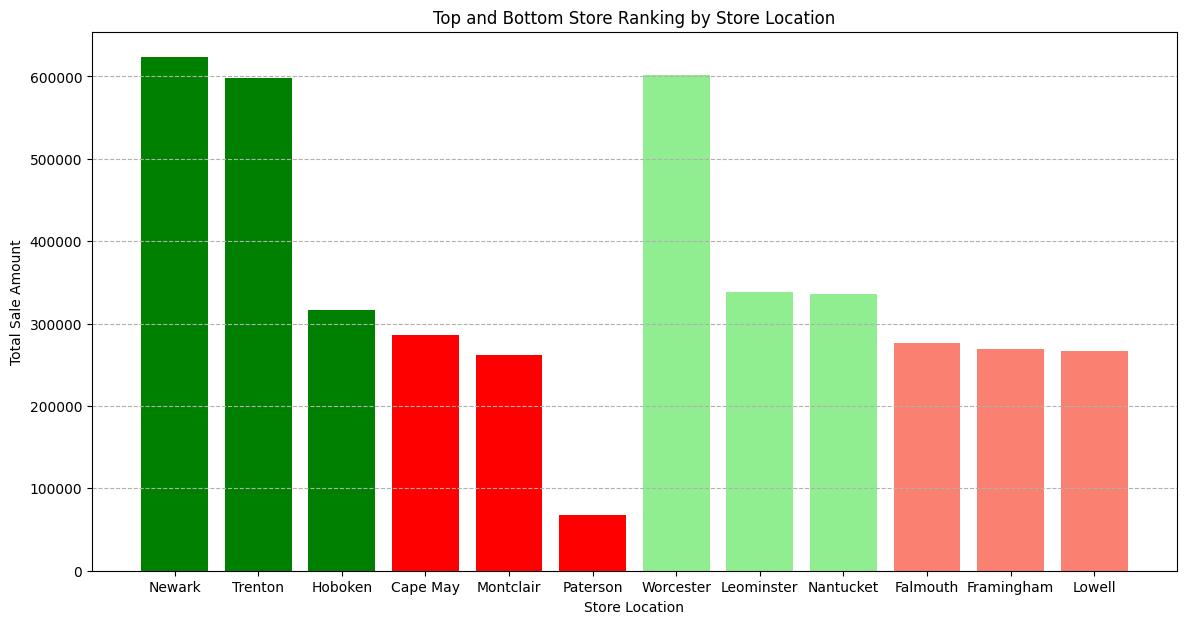

In [315]:
#bar chart for store performance
# have to combine the top/bottom  for a chart comparison
bar_chart = pd.concat([miami_top, miami_low, bo_top, bo_low])
#adding color to the graph based on top green, red bottom
bar_chart['color'] = ['green', 'green', 'green', 'red', 'red', 'red', 'lightgreen', 'lightgreen', 'lightgreen', 'salmon', 'salmon', 'salmon']
#have to adjust width and height
plt.figure(figsize=(14,7))
#whats going to be on the x and y axis
plt.bar(bar_chart['Store Location'], bar_chart['Sale Amount'], color=bar_chart['color'])

plt.xlabel('Store Location')
plt.ylabel('Total Sale Amount')
plt.title('Top and Bottom Store Ranking by Store Location')
plt.grid(axis='y', linestyle='--')
plt.show()



# Question 4
Comparing the customer ID from the customer list data with the rewards ID from the sales data,
who were the top customers in each sales territory?


### Comment
Miami's top rewards customer is Angel who has spent $2,218.26, and Bo's top rewards customer is Tracy Jordan who spent $3,041.06. The differnece between the two is Tracy spent $821.80 more then Angel. Bo customers top spend $2,300 and up while Miami's top spend under $2,200.

In [ ]:
#join merge df5 and df1 reward id and cust id
# can only merge two tables at a time have to use left on and right on 
#since cust id and rewardsid dont have the same name 
# hard time with this one it a long string name for the column 
#have to use split to separte the string to columns .iloc for row indexing
df1_split = df1.iloc[:, 0].str.split('|', expand=True)
# naming the columns individually
df1_split.columns = ['cust_id', 'date', 'time', 'name', 'email', 'phone', 'sms-opt-out']
#make sure both are integers for id column
#fillna to replace NaN with 0 vs missing value
df5['RewardsID'] = df5['RewardsID']. fillna(0).astype(int)
df1_split['cust_id'] = df1_split['cust_id'].astype(int)

merged_2= pd.merge(df1_split, df5, right_on='RewardsID', left_on='cust_id')
all_merged = pd.merge(merged_2, df4, on='Store ID')

# keep this from previous code to fliter manager
filtered_manager = all_merged[all_merged['Territory Manager'].isin(['Miami Vue', 'Bo Heap'])]

# total customer spending to find top customer
customer_money = filtered_manager.groupby(['Territory Manager', 'Store ID', 'cust_id', 'name'], as_index=False)['Sale Amount'].sum()

# customers to find the top ascending false high to low
#sort to show top customer ranking
top_customer = customer_money.sort_values(by='Sale Amount', ascending=False)
#.head to show only the 10 customers i dont need the rest
top_customer.head(10)


,Territory Manager,Store ID,cust_id,name,Sale Amount
2536,Bo Heap,813,384,Tracy Jordan,3041.06
3015,Bo Heap,816,188,Mellie Grant,2532.56
2359,Bo Heap,812,412,Big Bird,2295.47
3558,Miami Vue,824,307,Angel,2218.26
5615,Miami Vue,835,161,Lieutenant Duffy,2181.66
3206,Bo Heap,817,85,Dar Adal,2090.51
6409,Miami Vue,839,123,Lady Elaine,2084.57
3474,Miami Vue,824,32,Marge,2022.28
5230,Miami Vue,833,306,Cordelia Chase,2021.22
1123,Bo Heap,805,492,Lucy Ricardo,2014.30


# Question 5
What is the number of transactions per month by product category in each assigned territory?
What is total sales revenue per month by category? What might this tell you about the most
popular products, and where could there be opportunity for growth?

### Comment Count
I found the trnasaction count for each category over the 4 year period for both territory managers. And the sales revenue per month by category, from there i decided to get the top and bottom 3 categories for transaction count and revenue per month. For Miami top catergoryID 110 for month 2025-10(377count) & 2025-06(393count),product stationare/supplies , and categoryID 120 for month 2025-10, product tech/acessories(422count). Bo had the same top categoryID 120 for the same 2025-10(455count), and same categoryID 110 for the months 2025-06(428count) and 2025-04(446count). Both has the same low count categoryID 125 for bottom around the same time period and around the same count between 32~38.



In [367]:
#total overall category amount by yea/month
#join merge df5 and df3 prodnum and df4
merged_categories = pd.merge(df3, df5, on= 'Prod Num')
all_categories = pd.merge(merged_categories, df4, on='Store ID')
# keep this from previous code to fliter manager
filtered_manager = all_categories[all_categories['Territory Manager'].isin(['Miami Vue', 'Bo Heap'])]
#fix date to months
filtered_manager['Transaction Date'] = pd.to_datetime(filtered_manager['Transaction Date'])
#%Y full year 4 digit , %m month as number 01-12
filtered_manager['Year-Month'] =filtered_manager['Transaction Date'].dt.strftime('%Y-%m')

#transaction by categories monthly
transactions = filtered_manager.groupby(['Territory Manager', 'Year-Month', 'CategoryID'], as_index=False)['Transaction Date'].count()
#rename column to count 
transactions = transactions.rename(columns={'Transaction Date': 'Transaction Count'})
print(transactions)

#revenue per month by category
revenue = filtered_manager.groupby(['Territory Manager', 'Year-Month', 'CategoryID'], as_index=False)['Sale Amount'].sum()
print(revenue)



    Territory Manager Year-Month  CategoryID  Transaction Count
0             Bo Heap    2022-01         100                 73
1             Bo Heap    2022-01         110                106
2             Bo Heap    2022-01         115                 93
3             Bo Heap    2022-01         120                112
4             Bo Heap    2022-01         125                 41
..                ...        ...         ...                ...
571         Miami Vue    2025-12         110                227
572         Miami Vue    2025-12         115                189
573         Miami Vue    2025-12         120                281
574         Miami Vue    2025-12         125                 78
575         Miami Vue    2025-12         130                257

[576 rows x 4 columns]
    Territory Manager Year-Month  CategoryID  Sale Amount
0             Bo Heap    2022-01         100     12333.33
1             Bo Heap    2022-01         110      1138.12
2             Bo Heap    2022-01  

In [372]:
#top and bottom  for transaction count for miami
miami = transactions[transactions['Territory Manager'] == 'Miami Vue']
miami_top = miami.sort_values(by='Transaction Count', ascending=False).head(3)
miami_low = miami.sort_values(by='Transaction Count', ascending=False).tail(3)
print(miami_top, 'Miami top count')
print(miami_low, 'Miami low count')
print()
#top and bottom for bo
bo = transactions[transactions['Territory Manager'] == 'Bo Heap']
bo_top = bo.sort_values(by='Transaction Count', ascending=False).head(3)
bo_low = bo.sort_values(by='Transaction Count', ascending=False).tail(3)
print(bo_top, 'Bo top count')
print(bo_low, 'Bo low count')


#differce bo sold 33 more tech and same number 32 for low count books

    Territory Manager Year-Month  CategoryID  Transaction Count
561         Miami Vue    2025-10         120                422
535         Miami Vue    2025-06         110                393
559         Miami Vue    2025-10         110                377 Miami top count
    Territory Manager Year-Month  CategoryID  Transaction Count
298         Miami Vue    2022-02         125                 35
352         Miami Vue    2022-11         125                 35
316         Miami Vue    2022-05         125                 32 Miami low count

    Territory Manager Year-Month  CategoryID  Transaction Count
273           Bo Heap    2025-10         120                455
235           Bo Heap    2025-04         110                446
247           Bo Heap    2025-06         110                428 Bo top count
   Territory Manager Year-Month  CategoryID  Transaction Count
34           Bo Heap    2022-06         125                 38
10           Bo Heap    2022-02         125                 

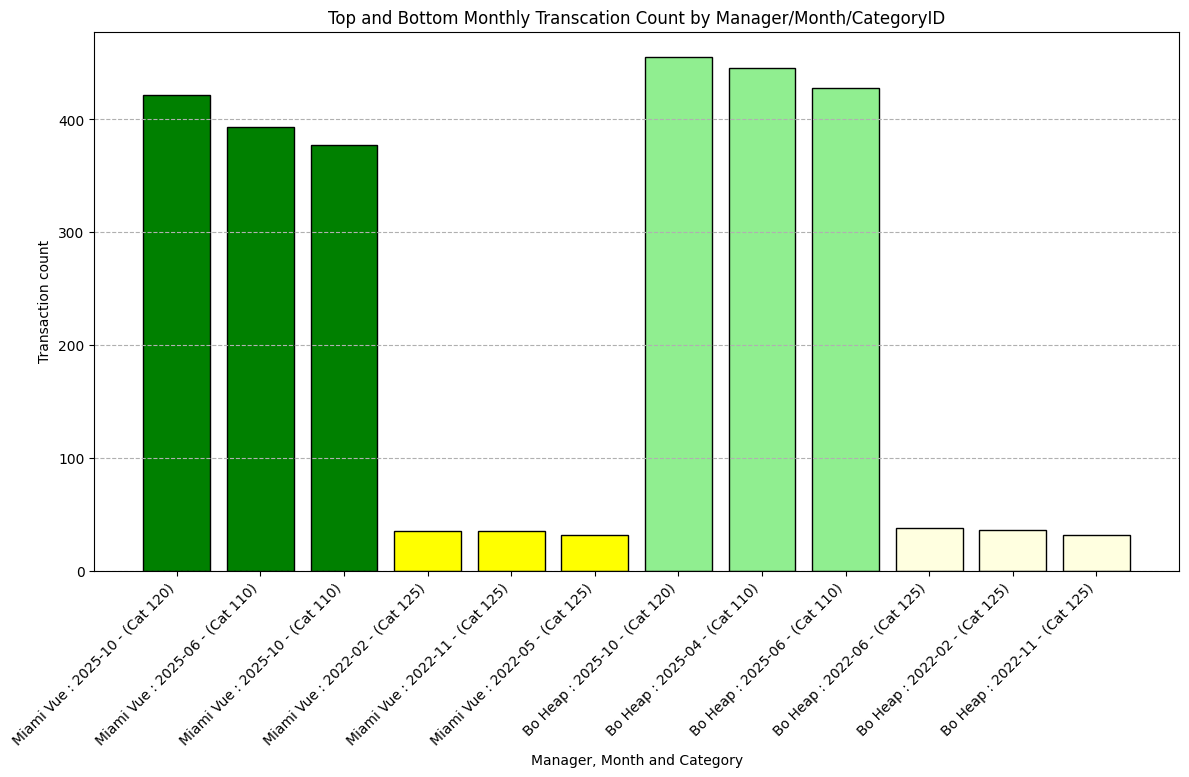

In [375]:
#chart for top and bottom transaction count
# use concate to combine
chart_2 = pd.concat([miami_top, miami_low, bo_top, bo_low])
chart_2['color'] = ['green', 'green', 'green', 'yellow', 'yellow', 'yellow', 'lightgreen', 'lightgreen', 'lightgreen', 'lightyellow', 'lightyellow', 'lightyellow']
# create a label ,combined string and integer
chart_2['Label'] = chart_2['Territory Manager'] + ' : ' + chart_2['Year-Month'] + ' - (Cat ' + chart_2['CategoryID'].astype(str) + ')'

#width/height of graph
plt.figure(figsize=(14,7))

plt.bar(chart_2['Label'], chart_2['Transaction Count'], color=chart_2['color'], edgecolor='black')
plt.xlabel('Manager, Month and Category')
plt.ylabel('Transaction count')
plt.title('Top and Bottom Monthly Transcation Count by Manager/Month/CategoryID')
#in order for everything to fit have to rotate the label
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.show()

### Graph comment
For this graph I used a bar graph to show the top 3 and bottom 3 categoryID's with Months by manager. As you can see 2025-10 catergory 120 ws the top for Miami and same for BO. While the bottom 3 categories you can see not much of difference with similar time periods.

### Comment Revenue
I also took the top 3/ bottom for reveune by catergoryID and month. Miami had categoryID 120 tech/acessories for months 9/10/12 in 2025 and Bo has the asme categoryID 120 tech/acessories for month 7/10/11 in 2025. And Both have the same bottom categoryID 125(books) /110(staionary/supplies) in 2022 both bottom making under a $1000.

In [369]:
#top/low revenue category id by manager miami
miami = revenue[revenue['Territory Manager'] == 'Miami Vue']
miami_top = miami.sort_values(by='Sale Amount', ascending=False).head(3)
miami_low = miami.sort_values(by='Sale Amount', ascending=False).tail(3)
print(miami_top, 'Miami top revenue')
print(miami_low, 'Miami lowest revenue')
print()
#bo heap top revenue/low
bo = revenue[revenue['Territory Manager'] == 'Bo Heap']
bo_top = bo.sort_values(by='Sale Amount', ascending=False).head(3)
bo_low = bo.sort_values(by='Sale Amount', ascending=False).tail(3)
print(bo_top, 'Bo top revenue')
print(bo_low, 'Bo lowest revenue')



    Territory Manager Year-Month  CategoryID  Sale Amount
561         Miami Vue    2025-10         120    192758.68
573         Miami Vue    2025-12         120    131024.14
555         Miami Vue    2025-09         120    127062.89 Miami top revenue
    Territory Manager Year-Month  CategoryID  Sale Amount
322         Miami Vue    2022-06         125       967.68
301         Miami Vue    2022-03         110       960.53
316         Miami Vue    2022-05         125       759.83 Miami lowest revenue

    Territory Manager Year-Month  CategoryID  Sale Amount
273           Bo Heap    2025-10         120    213921.34
279           Bo Heap    2025-11         120    151890.30
255           Bo Heap    2025-07         120    149927.28 Bo top revenue
   Territory Manager Year-Month  CategoryID  Sale Amount
37           Bo Heap    2022-07         110       867.49
13           Bo Heap    2022-03         110       814.34
64           Bo Heap    2022-11         125       775.55 Bo lowest revenue


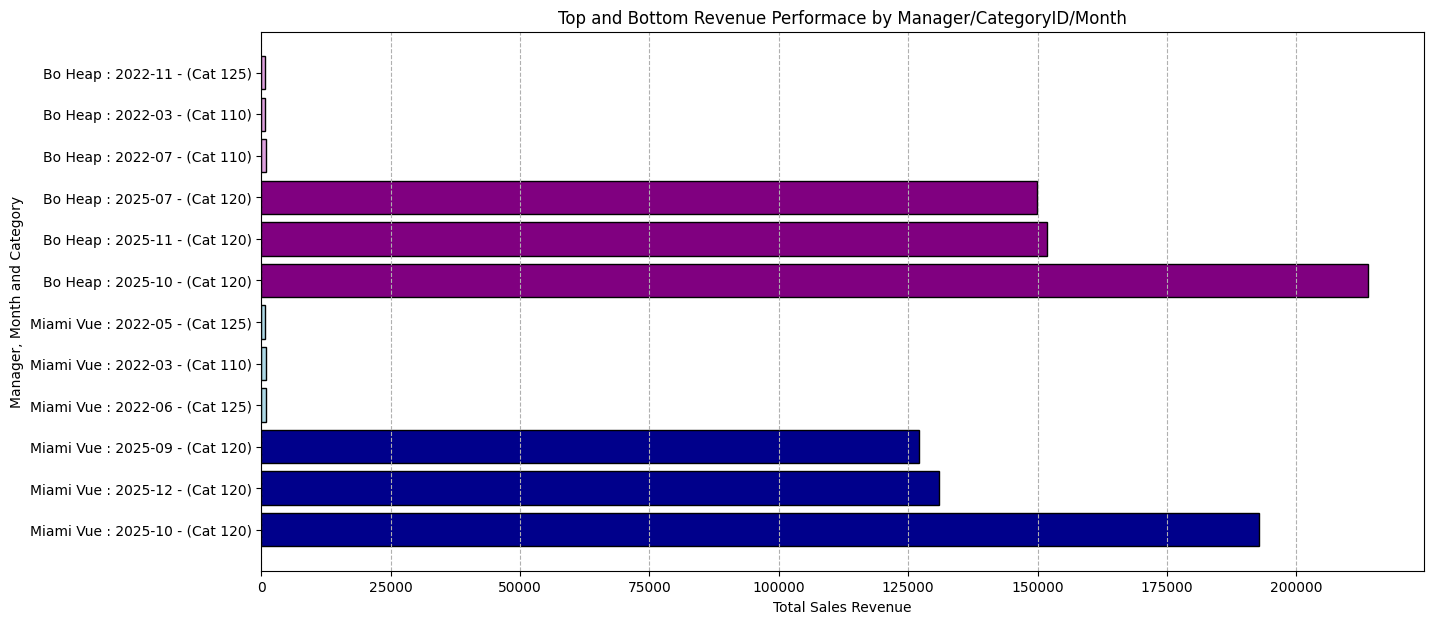

In [370]:
#chart for revenue
chart_3 = pd.concat([miami_top, miami_low, bo_top, bo_low])
chart_3['color'] = ['darkblue', 'darkblue', 'darkblue', 'lightblue', 'lightblue', 'lightblue', 'purple', 'purple', 'purple', 'plum', 'plum', 'plum']
# create a label ,combined string and integer
chart_3['Label'] = chart_3['Territory Manager'] + ' : ' + chart_3['Year-Month'] + ' - (Cat ' + chart_3['CategoryID'].astype(str) + ')'

#width/height of graph
plt.figure(figsize=(15,7))
#used barh horizontal graph bar
plt.barh(chart_3['Label'], chart_3['Sale Amount'], color=chart_3['color'], edgecolor='black')
#plt.bar(chart_3['Label'], chart_3['Sale Amount'], color=chart_3['color'], edgecolor='black')
plt.xlabel('Total Sales Revenue')
plt.ylabel('Manager, Month and Category')
plt.title('Top and Bottom Revenue Performace by Manager/CategoryID/Month')
#add grid line easier to follow graph sale revenue
plt.grid(axis='x', linestyle='--')
plt.show()

### Graph Comment
In this graph I did a horizontal bar chart I took the top 3/ bottom three categoryID's that make the most and least revneue to see the comparison between managers. Miami top revenue is $192,758.38(2025-10/120) and bottom revenue $759.83. Bo's top revenue is $213,921.34(2025-10/120) and bottom is $775.55. Bo out performed by $21,162.96 more then Miami's top. And the bottom revenue had a $15.72 less for Miami.

In [366]:
categories_only = df2[df2['CategoryID'].isin([120,125,110])][['CategoryID', 'Category']].drop_duplicates()
categories_only

,CategoryID,Category
0,120,Technology & Accessories
12,125,Books (General)
13,110,Stationery and Supplies


# Question 6
What is your recommendation for where to focus marketing attention in the next quarter?

## My Recommendation
Based of the data I have analyzed, it is pretty clear that both territory managers have similaries. For Miami Vue her top category is 120 tech/accessories and the lowest selling category is 125 books. Same goes for her competetor Bo heap, he had the same top and low selling categories. The only main diffence is Bo out performed Miami in revenue sales during the same Year-Month(2025-10) by $21,162.96 more in tech products. This causes a gap in instore sales revenue for Miami. Both have similar transaction count numbers for top and bottom categries sold. When taking a deeper look at individual sales by cateroryID, Year-Month, product, and sales amount; I can see that tech/acessories have computer products items selling at above $9000, and the lower sales category Stationery/Supplies has items as low as $2.40. Even though Stationery/Supplies had hign transaction count with tech/acessories it doesn't have a high value impact like tech/acessories does. My recommendation is to up sell tech producst as it has the highest revenue impact and item count. Also Miami Vue should focus on the low performing store in Preston where the biggest sale amount gap is of -$199,870.26 compared to Bo's lowest performing store. If we can get that store to upsell more tech items monthly to get a steady growth over time by doing promotion and bundles before the peak months(possible back to school sales or holiday sales) (9/10/12) then we can try and close the gap bewteen Bo's lowest selling store. This can also dive up the rewards members and sale amount per rewards member. Doing excluisve member only sales or memeber only prices on high demand tech/acessory products we can get people to sign up and spend more. This will have a better overall store performance and revenue impact over time.  

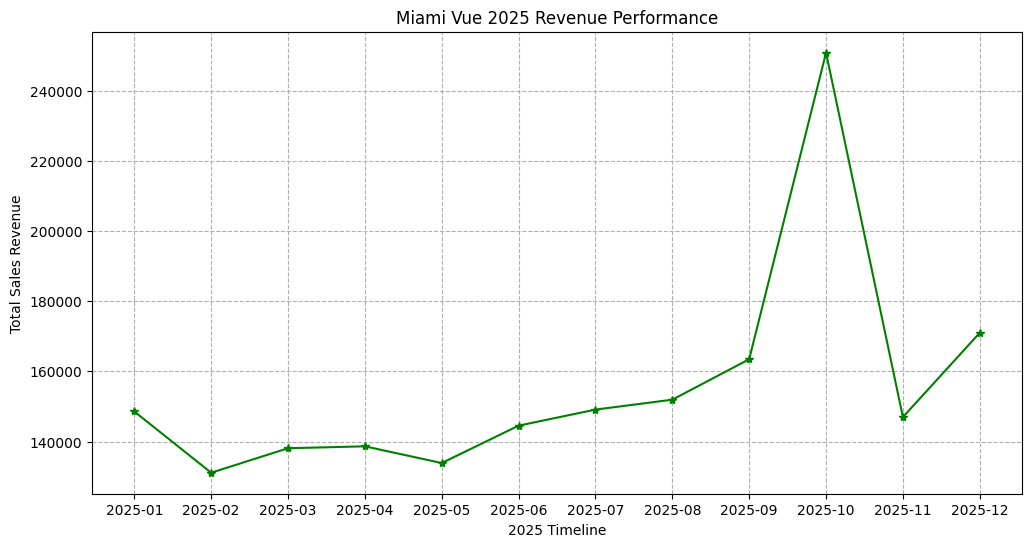

In [ ]:
#miami only revenue sales for 2025
#filter manager
miami = revenue[revenue['Territory Manager'] == 'Miami Vue']
#interger date to string
miami['Year-Month'] = miami['Year-Month'].astype(str)
#filter 2025 using startswith
miami_25 = miami[miami['Year-Month'].str.startswith('2025')]

#only need year/month and sale amount
miami_monthly = miami_25.groupby('Year-Month', as_index=False)['Sale Amount'].sum()
miami_monthly = miami_monthly.sort_values(by='Year-Month')
#line graph
plt.figure(figsize=(12,6))
#x and y axis fro line graph, used star markers
plt.plot(miami_monthly['Year-Month'], miami_monthly['Sale Amount'], marker='*', color='green', linestyle='-')
plt.xlabel('2025 Timeline')
plt.ylabel('Total Sales Revenue')
plt.title('Miami Vue 2025 Revenue Performance')
#added grid lines to help distinguish marker
plt.grid(True, linestyle='--')
plt.show()


### Comment 
This gets a deeper dive to what question 6 was asking, product individual sale amount by year/month vs the top/ bottom 3 was a category sale amount total by year/month

In [362]:
#this a product individual sale amount by year/month vs the top/ bottom 3 was a category sale amount total by year/month
#same code from before
merged_categories = pd.merge(df3, df5, on='Prod Num')
all_categories = pd.merge(merged_categories, df4, on='Store ID')
#merged df2 with df3,df5, and df4 to get the categoryid and subcategory
all_categories = pd.merge(all_categories, df2, on=['CategoryID', 'SubcategoryID'])
filtered_manager = all_categories[all_categories['Territory Manager'].isin(['Miami Vue', 'Bo Heap'])]
#same code from pervious
filtered_manager['Transaction Date'] = pd.to_datetime(filtered_manager['Transaction Date'])
filtered_manager['Year-Month'] = filtered_manager['Transaction Date'].dt.strftime('%Y-%m')

#individual product sale amount to find high price items
prod_rev = filtered_manager.groupby(['Territory Manager', 'Year-Month', 'CategoryID', 'Category', 'Product'], as_index=False)['Sale Amount'].sum()
miami = prod_rev[prod_rev['Territory Manager'] == 'Miami Vue']
miami_top = miami.sort_values(by='Sale Amount', ascending=False).head(5)
miami_low = miami.sort_values(by='Sale Amount', ascending=False).tail(5)
print(miami_top)
print()
print(miami_low)

      Territory Manager Year-Month  CategoryID                  Category  \
31346         Miami Vue    2025-02         120  Technology & Accessories   
34261         Miami Vue    2025-10         120  Technology & Accessories   
34307         Miami Vue    2025-10         120  Technology & Accessories   
29572         Miami Vue    2024-09         120  Technology & Accessories   
25431         Miami Vue    2023-10         120  Technology & Accessories   

                        Product  Sale Amount  
31346           MSI Creator Z16     10582.20  
34261  Acer Chromebook Spin 713      9060.10  
34307     Lenovo IdeaPad Flex 5      9060.10  
29572   Chromebook Pixelbook Go      9041.97  
25431   Chromebook Pixelbook Go      9041.97  

      Territory Manager Year-Month  CategoryID                 Category  \
19230         Miami Vue    2022-05         110  Stationery and Supplies   
30562         Miami Vue    2024-12         110  Stationery and Supplies   
17936         Miami Vue    2022-01 

In [ ]:
#scikit learn using line graph
!pip install scikit-learn
from sklearn.linear_model import LinearRegression


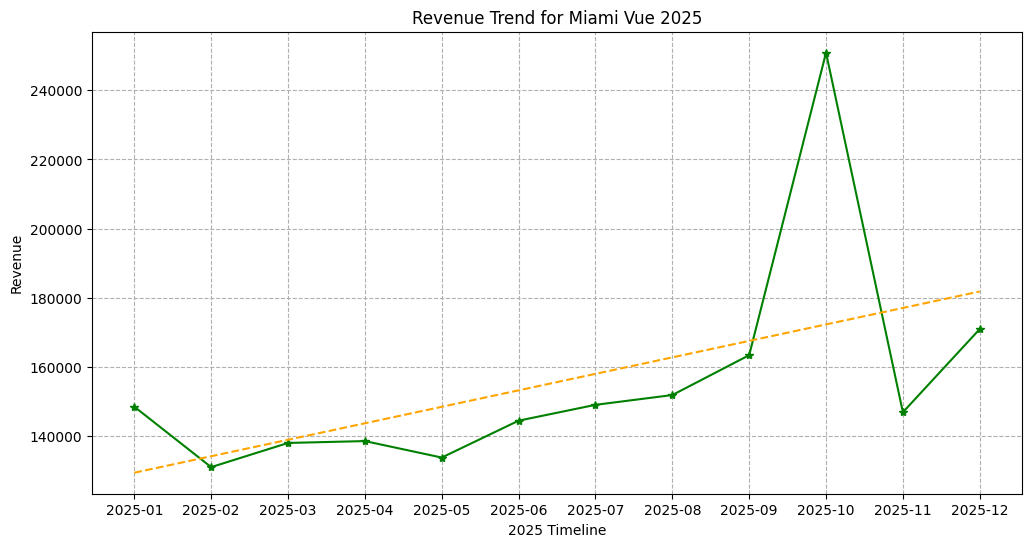

In [ ]:
#line graph to show revneue over time 
#scikit only uses simple numbers have to change my year-month date
#using range to get months as 1-12
miami_monthly['Month_Number'] = range(1, len(miami_monthly) + 1)

#X,y are standard variable names to represent data
#x-input, y-output
#machine learinig use only
X = miami_monthly[['Month_Number']]
y = miami_monthly['Sale Amount']

model = LinearRegression()
#X,y -X has many values and y only has one
#.fit() trains the model
model.fit(X,y)
predictions = model.predict(X)
#use plt to plot and make line prediction
#x and y axis for graph
#use original name for x , y stays the same
plt.figure(figsize=(12,6))
#useyear-month to show the original format from graph 
plt.plot(miami_monthly['Year-Month'], y, marker='*', label='Actual Sales', color='green')
#prediction line
plt.plot(miami_monthly['Year-Month'], predictions, linestyle='--', color='orange', label='Trend Prediction')
plt.xlabel('2025 Timeline')
plt.ylabel('Revenue')
plt.title('Revenue Trend for Miami Vue 2025')
plt.grid(True, linestyle='--')
plt.show()




### Graph Comment
Linera regression shows that there is a increase in sales revenue over the months in 2025, this is a good sign room for improvement to keep increasing over time